In [3]:
import pandas as pd
df = pd.read_csv("data/ads.csv")
df.columns

Index(['id', 'ad_creation_time', 'ad_delivery_start_time', 'bylines',
       'currency', 'page_id', 'page_name', 'ad_creative_bodies',
       'ad_creative_link_captions', 'ad_creative_link_descriptions',
       'ad_creative_link_titles', 'audience_size_lower', 'impressions_lower',
       'impressions_upper', 'spend_lower', 'spend_upper', 'ad_snapshot_url',
       'language_en', 'language_es', 'language_other', 'platform_fb',
       'platform_ig', 'platform_other', '13-17/female', '13-17/male',
       '13-17/unknown', '18-24/female', '18-24/male', '18-24/unknown',
       '25-34/female', '25-34/male', '25-34/unknown', '35-44/female',
       '35-44/male', '35-44/unknown', '45-54/female', '45-54/male',
       '45-54/unknown', '55-64/female', '55-64/male', '55-64/unknown',
       '65+/female', '65+/male', '65+/unknown', 'Unknown/female',
       'Unknown/male', 'Unknown/unknown'],
      dtype='object')

In [ ]:
buzz_df = df.copy()

buzz_df['year'] = pd.to_datetime(buzz_df['ad_creation_time']).dt.year
buzz_df = buzz_df[buzz_df['ad_creative_bodies'].notna()]

buzz_df['clean_text'] = buzz_df['ad_creative_bodies'].str.lower()

demo_cols = [col for col in buzz_df.columns if '/' in col]
demo_cols = [col for col in demo_cols if not col.startswith('Unknown/')]

age_ranges = sorted(set(col.split('/')[0] for col in demo_cols))
genders = sorted(set(col.split('/')[1] for col in demo_cols))

# age totals
for age in age_ranges:
    age_specific_cols = [col for col in demo_cols if col.startswith(age + '/')]
    buzz_df[f'age_{age}_total'] = buzz_df[age_specific_cols].sum(axis=1)

age_total_cols = [f'age_{age}_total' for age in age_ranges]

# gender totals
for gender in genders:
    gender_specific_cols = [col for col in demo_cols if col.endswith('/' + gender)]
    buzz_df[f'gender_{gender}_total'] = buzz_df[gender_specific_cols].sum(axis=1)

gender_total_cols = [f'gender_{gender}_total' for gender in genders]

# original gender + age totals
age_gender_cols = demo_cols.copy()

buzz_df.head()

In [6]:

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

buzz_df = buzz_df.copy()
buzz_df['year'] = pd.to_datetime(buzz_df['ad_creation_time']).dt.year
buzz_df = buzz_df[buzz_df['ad_creative_bodies'].notna()]
buzz_df['clean_text'] = buzz_df['ad_creative_bodies'].str.lower()

years = sorted(buzz_df['year'].unique())

top_words_by_year = {}

for year in years:
    
    year_df = buzz_df[buzz_df['year'] == year]
    
    if len(year_df) < 50:
        continue
    
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        min_df=5,
        ngram_range=(1,1)
    )
    
    X = vectorizer.fit_transform(year_df['clean_text'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    tfidf_means = np.asarray(X.mean(axis=0)).flatten()
    top_indices = tfidf_means.argsort()[-100:][::-1]
    top_words = feature_names[top_indices]
    
    top_words_by_year[year] = set(top_words)

In [7]:
for year, words in top_words_by_year.items():
    print(f"\nTop 100 Buzzwords for {year}:\n")
    print(sorted(list(words)))


Top 100 Buzzwords for 2020:

['000', '10', '19', '2020', 'account', 'ad', 'advertising', 'america', 'americans', 'ballot', 'biden', 'black', 'campaign', 'care', 'change', 'click', 'com', 'community', 'congress', 'country', 'covid', 'day', 'democrats', 'disabled', 'disclaimer', 'don', 'donate', 'election', 'ensure', 'fair', 'families', 'fight', 'following', 'free', 'georgia', 'great', 'help', 'hey', 'https', 'information', 'joe', 'join', 'just', 'know', 'later', 'learn', 'let', 'like', 'mail', 'make', 'national', 'need', 'new', 'news', 'november', 'office', 'open', 'org', 'page', 'people', 'petition', 'political', 'power', 'president', 'protect', 'public', 'quiz', 'ran', 'register', 'request', 'required', 'right', 'run', 'safe', 'save', 'sees', 'senate', 'share', 'shirt', 'sign', 'stand', 'standards', 'state', 'states', 'stop', 'support', 'sure', 'tax', 'think', 'time', 'today', 'trump', 'use', 'vote', 'voter', 'voting', 'want', 'world', 'www', 'yes']

Top 100 Buzzwords for 2021:

['20

In [12]:
buzz_df['dominant_age'] = buzz_df[age_total_cols].idxmax(axis=1)
buzz_df['dominant_age'] = buzz_df['dominant_age'].str.replace('age_', '').str.replace('_total', '')
top_100_buzzwords = list(set.union(*top_words_by_year.values()))


### chi-square test of homogeneity

null hypothesis: the distribution of buzzwords is the same across age groups

alt hypothesis: the distribution of buzzwords differs acrossage groups (evidence of micro-targeting)



In [ ]:
from scipy import stats

results = []
bonferroni_alpha = 0.05 / len(top_100_buzzwords)

for word in top_100_buzzwords:
    buzz_df['has_word'] = buzz_df['clean_text'].str.contains(r'\b' + word + r'\b', regex=True)
    contingency = pd.crosstab(buzz_df['dominant_age'], buzz_df['has_word'])
    
    T_stat, p_value, dof, expected_freq = stats.chi2_contingency(contingency)
    
    results.append({
        'buzzword': word,
        'T_stat': round(T_stat, 4),
        'p_value': p_value,
        'dof': dof,
        'significant': p_value < bonferroni_alpha
    })

results_df = pd.DataFrame(results).sort_values('p_value')
results_df

In [16]:
sig_words = results_df[results_df['significant'] == True]

for i, row in results_df.iterrows():
    if row['significant']:
        print(f"For buzzword '{row['buzzword']}', we reject the null hypothesis that its distribution is the same across age groups. (T={row['T_stat']}, p={row['p_value']:.4e})")
    else:
        print(f"For buzzword '{row['buzzword']}', we fail to reject the null hypothesis that its distribution is the same across age groups.")


For buzzword 'trump', we reject the null hypothesis that its distribution is the same across age groups. (T=1860.9577, p=0.0000e+00)
For buzzword 'required', we reject the null hypothesis that its distribution is the same across age groups. (T=6116.5275, p=0.0000e+00)
For buzzword 'disclaimer', we reject the null hypothesis that its distribution is the same across age groups. (T=6351.0972, p=0.0000e+00)
For buzzword 'ad', we reject the null hypothesis that its distribution is the same across age groups. (T=5842.4976, p=0.0000e+00)
For buzzword 'ran', we reject the null hypothesis that its distribution is the same across age groups. (T=6128.2907, p=0.0000e+00)
For buzzword 'sale', we reject the null hypothesis that its distribution is the same across age groups. (T=981.2378, p=1.0213e-208)
For buzzword 'register', we reject the null hypothesis that its distribution is the same across age groups. (T=908.7964, p=4.7112e-193)
For buzzword 'just', we reject the null hypothesis that its dist

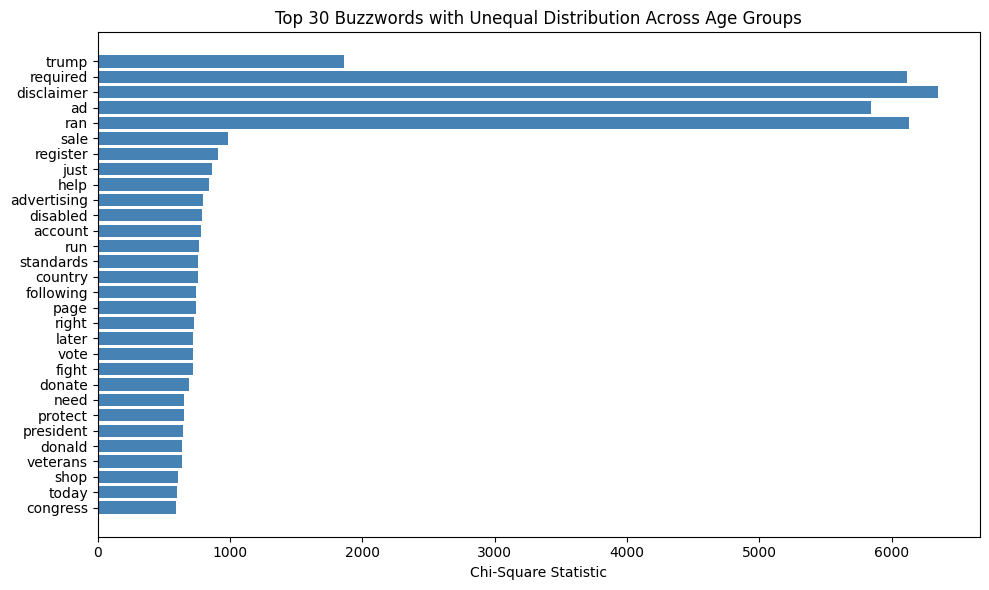

In [18]:
top_sig = sig_words.head(30)

plt.figure(figsize=(10, 6))
plt.barh(top_sig['buzzword'], top_sig['T_stat'], color='steelblue')
plt.xlabel('Chi-Square Statistic')
plt.title('Top 30 Buzzwords with Unequal Distribution Across Age Groups')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()